<a href="https://colab.research.google.com/github/Vyshnavi262007/AI-ML-Projects/blob/main/Dataaugmentation%2Bmobilenetv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
import zipfile
import os

zip_path = "/content/archive.zip"
extract_path = "/content/cat_dog_dataset"

# Extract the ZIP
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Dataset path
train_path = "/content/cat_dog_dataset/train"

print("Dataset path:", train_path)
print("Classes:", os.listdir(train_path))

Dataset path: /content/cat_dog_dataset/train
Classes: ['classname.txt', 'dog', 'cat']


In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=16,
    label_mode="binary"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=16,
    label_mode="binary"
)

print("Classes:", train_dataset.class_names)

Found 275 files belonging to 2 classes.
Using 220 files for training.
Found 275 files belonging to 2 classes.
Using 55 files for validation.
Classes: ['cat', 'dog']


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

print("Data augmentation created!")

Data augmentation created!


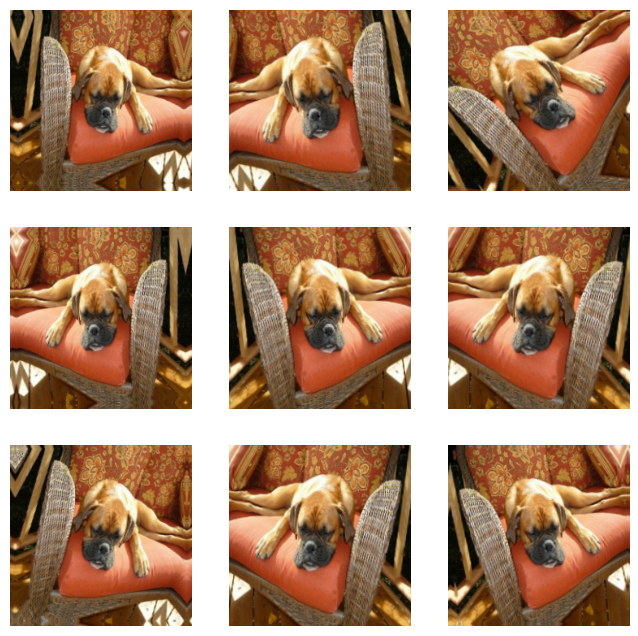

In [ ]:
for images, labels in train_dataset.take(1):
    sample_image = images[0]
    break

plt.figure(figsize=(8, 8))

for i in range(9):
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, 0),
        training=True
    )

    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.axis("off")

plt.show()

In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("MobileNetV2 loaded successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 loaded successfully!


In [ ]:
base_model.trainable = False

print("MobileNetV2 is frozen!")

MobileNetV2 is frozen!


In [ ]:
model = tf.keras.Sequential([
    data_augmentation,

    # Convert pixel values from 0-255 to -1 to 1
    layers.Rescaling(1./127.5, offset=-1),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

print("Corrected model created successfully!")

Corrected model created successfully!


In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (1, 7, 7, 1280)        │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (1, 1280)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 1)                 │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8955 - loss: 0.2968 - val_accuracy: 1.0000 - val_loss: 0.0651
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9818 - loss: 0.0780 - val_accuracy: 1.0000 - val_loss: 0.0283
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 940ms/step - accuracy: 1.0000 - loss: 0.0257 - val_accuracy: 1.0000 - val_loss: 0.0208
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 969ms/step - accuracy: 0.9955 - loss: 0.0224 - val_accuracy: 1.0000 - val_loss: 0.0127
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 965ms/step - accuracy: 0.9909 - loss: 0.0213 - val_accuracy: 1.0000 - val_loss: 0.0112


In [ ]:
print("Total MobileNetV2 layers:", len(base_model.layers))
print("Trainable:", base_model.trainable)

Total MobileNetV2 layers: 154
Trainable: False


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:140]:
    layer.trainable = False

for layer in base_model.layers[140:]:
    layer.trainable = True

print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Total layers: 154
Trainable layers: 14


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled!")

Fine-tuning model compiled!


In [ ]:
history_finetune = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9273 - loss: 0.2831 - val_accuracy: 1.0000 - val_loss: 0.0092
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9545 - loss: 0.1462 - val_accuracy: 1.0000 - val_loss: 0.0079
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9500 - loss: 0.1536 - val_accuracy: 1.0000 - val_loss: 0.0071
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9682 - loss: 0.0992 - val_accuracy: 1.0000 - val_loss: 0.0067
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9682 - loss: 0.1243 - val_accuracy: 1.0000 - val_loss: 0.0064


In [ ]:
loss, accuracy = model.evaluate(validation_dataset)

print("Fine-Tuned Validation Loss:", loss)
print("Fine-Tuned Validation Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 411ms/step - accuracy: 1.0000 - loss: 0.0064
Fine-Tuned Validation Loss: 0.0063617839477956295
Fine-Tuned Validation Accuracy: 1.0


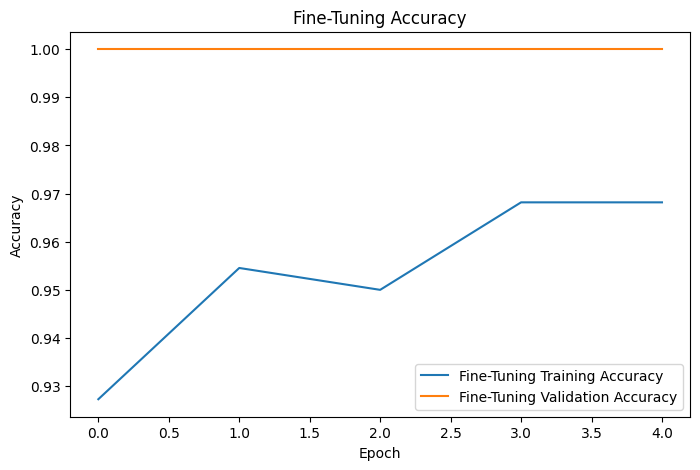

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_finetune.history["accuracy"],
    label="Fine-Tuning Training Accuracy"
)

plt.plot(
    history_finetune.history["val_accuracy"],
    label="Fine-Tuning Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tuning Accuracy")
plt.legend()

plt.show()

In [ ]:
model.save("/content/cat_dog_mobilenetv2_finetuned.keras")

print("Fine-tuned model saved successfully!")

Fine-tuned model saved successfully!


In [ ]:
prediction = model.predict(img_array)

score = prediction[0][0]

if score >= 0.5:
    result = "DOG 🐶"
    confidence = score * 100
else:
    result = "CAT 🐱"
    confidence = (1 - score) * 100

print("Prediction:", result)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: CAT 🐱
Confidence: 100.0 %
